In [1]:
import xarray as xr
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from importlib import reload
import matplotlib.pyplot as plt
import seaborn as sns
import data_processing
import random

In [2]:
h2o_data = xr.open_dataset('ACEFTS_L2_v5p2_H2O.nc')
h2o_flags = xr.open_dataset('ACEFTS_L2_v5p2_flags_H2O.nc')

In [3]:
h2o_data = h2o_data.set_index(index=['orbit', 'sunset_sunrise'])
h2o_flags = h2o_flags.set_index(index=['orbit', 'sunset_sunrise'])

In [4]:
def encode_time_features(year, month, day, hour):
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)
    day_sin = np.sin(2 * np.pi * day / 31)
    day_cos = np.cos(2 * np.pi * day / 31)
    hour_sin = np.sin(2 * np.pi * hour / 24)
    hour_cos = np.cos(2 * np.pi * hour / 24)
    year_normalized = (year - 2004) / (20)
    return [year_normalized, month_sin, month_cos, day_sin, day_cos, hour_sin, hour_cos]

In [5]:
reload(data_processing)
import data_processing
from data_processing import preprocess_profile_data as ppd

In [6]:
date_indices = np.arange(len(h2o_data['year'].values))

In [7]:
features, labels, feature_date_indices = ppd('H2O', 
                                             h2o_data, 
                                             h2o_flags, 
                                             date_indices, 
                                             n_surrounding = 4, 
                                             n_altitudes = len(h2o_data['altitude'].values),
                                             filter_indices = True
                                             )

VMR for date index 256 is empty after screening
VMR for date index 1753 is empty after screening
VMR for date index 2319 is empty after screening
VMR for date index 2506 is empty after screening
VMR for date index 4293 is empty after screening
VMR for date index 4316 is empty after screening
VMR for date index 4591 is empty after screening
VMR for date index 4683 is empty after screening
VMR for date index 4695 is empty after screening
VMR for date index 4773 is empty after screening
VMR for date index 5448 is empty after screening
VMR for date index 5617 is empty after screening
VMR for date index 5743 is empty after screening
VMR for date index 6082 is empty after screening
VMR for date index 6844 is empty after screening
VMR for date index 7916 is empty after screening
VMR for date index 7917 is empty after screening
VMR for date index 7977 is empty after screening
VMR for date index 7989 is empty after screening
VMR for date index 8142 is empty after screening
VMR for date index 83

In [8]:
features.shape

(125194, 5, 150, 11)

In [9]:
labels.shape
unique, counts = np.unique(labels, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(124340), np.int64(1): np.int64(854)}


In [10]:
from keras import layers, models

In [11]:
import tensorflow as tf

def binary_accuracy_with_threshold(y_true, y_pred):
    """
    Custom accuracy metric for binary classification with a threshold.
    """
    y_pred_discrete = tf.cast(y_pred > 0.5, tf.float32)
    return tf.keras.metrics.binary_accuracy(y_true, y_pred_discrete)

In [12]:
from keras.optimizers import Adam

optimizer = Adam(learning_rate=1e-4)  # Lower the learning rate

# Define the CNN-LSTM model
def build_cnn_lstm_model(n_profiles, n_altitudes, n_features):
    """
    Builds a CNN-LSTM model for profile classification.

    Parameters:
    - n_profiles: Number of profiles per sample.
    - n_altitudes: Number of altitude levels per profile.
    - n_features: Number of features per altitude.

    Returns:
    - model: Compiled CNN-LSTM model.
    """
    input_shape = (n_profiles, n_altitudes, n_features)

    # Input layer
    inputs = tf.keras.Input(shape=input_shape)

    # Time-distributed CNN layers
    cnn = layers.TimeDistributed(
        models.Sequential([
            layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(n_altitudes, n_features)),
            layers.MaxPooling1D(pool_size=2),
            layers.Conv1D(filters=128, kernel_size=3, activation='relu'),
            layers.MaxPooling1D(pool_size=2),
            layers.Flatten()
        ])
    )(inputs)

    # LSTM layers
    lstm = layers.LSTM(128, return_sequences=False)(cnn)

    # Fully connected layers
    dense = layers.Dense(64, activation='relu')(lstm)
    outputs = layers.Dense(1, activation='sigmoid')(dense)  # Binary classification

    # Build the model
    model = models.Model(inputs=inputs, outputs=outputs)

    # Compile the model
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[binary_accuracy_with_threshold])

    return model


In [13]:
n_profiles = 5
n_altitudes = len(h2o_data['altitude'].values)
n_features = 11

model = build_cnn_lstm_model(n_profiles, n_altitudes, n_features)

/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
from keras._tf_keras.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [15]:
# Split the data into training, validation, and test sets
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(features, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [16]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

In [140]:
import numpy as np

# Compute raw class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Apply logarithmic scaling
smoothed_weights = np.log1p(class_weights)

# Convert to dictionary for Keras
class_weights_dict = {i: smoothed_weights[i] for i in range(len(smoothed_weights))}

In [141]:
intermediate_weights = (class_weights + smoothed_weights)/2

class_weights_dict = {i: intermediate_weights[i] for i in range(len(intermediate_weights))}

Epoch 1/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 91s 63ms/step - binary_accuracy_with_threshold: 0.5524 - loss: 0.7054 - val_binary_accuracy_with_threshold: 0.7136 - val_loss: 0.6500
Epoch 2/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 87s 64ms/step - binary_accuracy_with_threshold: 0.6267 - loss: 0.6694 - val_binary_accuracy_with_threshold: 0.6283 - val_loss: 0.6707
Epoch 3/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 90s 66ms/step - binary_accuracy_with_threshold: 0.5608 - loss: 0.6638 - val_binary_accuracy_with_threshold: 0.7656 - val_loss: 0.5454
Epoch 4/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 91s 67ms/step - binary_accuracy_with_threshold: 0.5963 - loss: 0.6594 - val_binary_accuracy_with_threshold: 0.6919 - val_loss: 0.5770
Epoch 5/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 91s 66ms/step - binary_accuracy_with_threshold: 0.6675 - loss: 0.6148 - val_binary_accuracy_with_threshold: 0.7528 - val_loss: 0.5402
Epoch 6/30
1370/1370 ━━━━━━━━━━━━━━━━━━━━ 92s 67ms/step - binary_accuracy_with_threshold: 0.7097 - loss: 0.5714 - val_bi

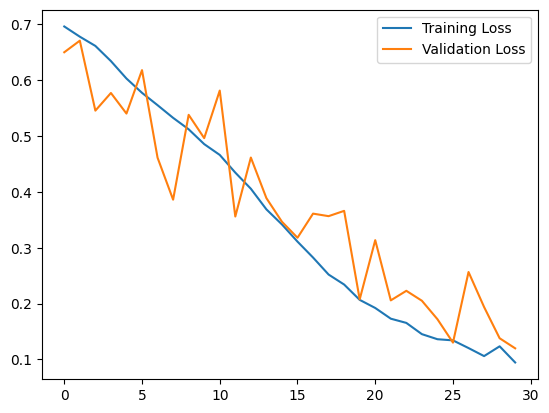

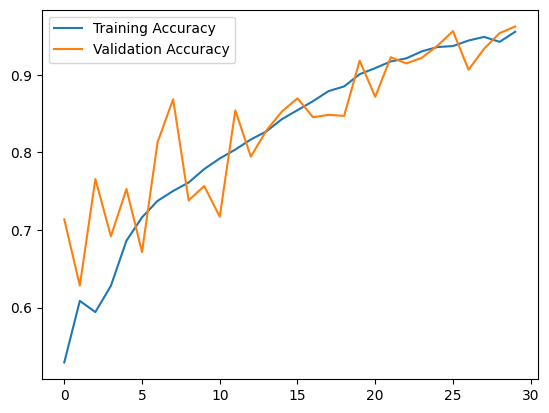

In [17]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    class_weight=class_weight_dict
)

plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['binary_accuracy_with_threshold'], label='Training Accuracy')
plt.plot(history.history['val_binary_accuracy_with_threshold'], label='Validation Accuracy')
plt.legend()
plt.show()

587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     18655
           1       0.04      0.18      0.06       125

    accuracy                           0.96     18780
   macro avg       0.52      0.57      0.52     18780
weighted avg       0.99      0.96      0.98     18780



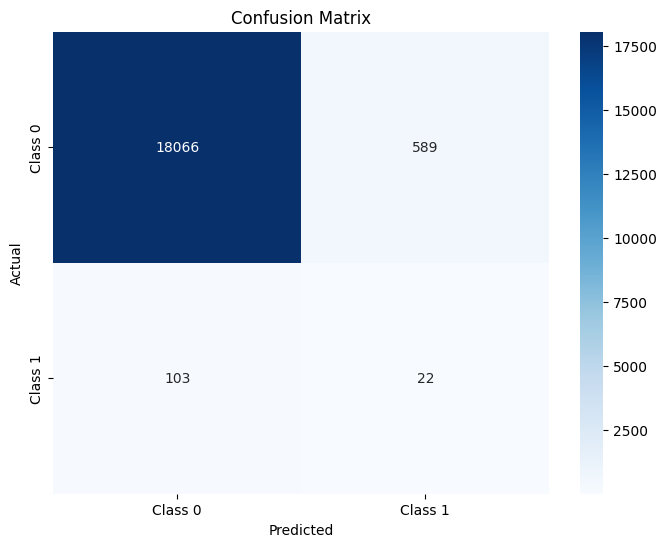

In [79]:
# Get predictions
predictions = model.predict(X_test)

# Convert probabilities to discrete labels
discrete_predictions = (predictions > 0.5).astype(int)

# Print classification report
print(classification_report(y_test, discrete_predictions))

# Plot confusion matrix
conf_matrix = confusion_matrix(y_test, discrete_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [25]:
predicted_bad_indices = np.where(discrete_predictions == 1)[0]
print(predicted_bad_indices)

[    8    12    23   112   139   148   195   237   250   316   329   331
   375   515   615   644   745   747   774   777   781   802   869   903
   922   940  1044  1079  1124  1134  1146  1191  1211  1214  1231  1249
  1254  1306  1349  1383  1439  1441  1450  1458  1495  1549  1574  1648
  1658  1690  1723  1725  1846  1853  1859  1886  1901  1905  1918  1952
  2015  2021  2055  2142  2153  2187  2227  2252  2256  2291  2302  2432
  2518  2563  2600  2619  2623  2664  2724  2755  2765  2781  2804  2810
  2816  2823  2895  3032  3052  3064  3069  3109  3173  3198  3232  3239
  3295  3307  3332  3353  3379  3406  3469  3485  3543  3557  3577  3607
  3611  3622  3658  3668  3763  3769  3777  3825  3865  3889  3931  3973
  3977  4007  4064  4085  4090  4163  4166  4173  4189  4196  4229  4240
  4255  4307  4317  4439  4512  4557  4562  4574  4587  4591  4633  4716
  4718  4725  4758  4812  4814  4824  4838  4844  4884  4923  4929  4959
  4971  4993  4995  5006  5035  5067  5068  5099  5

In [26]:
pred_bad_date_indices = feature_date_indices[predicted_bad_indices]

3353


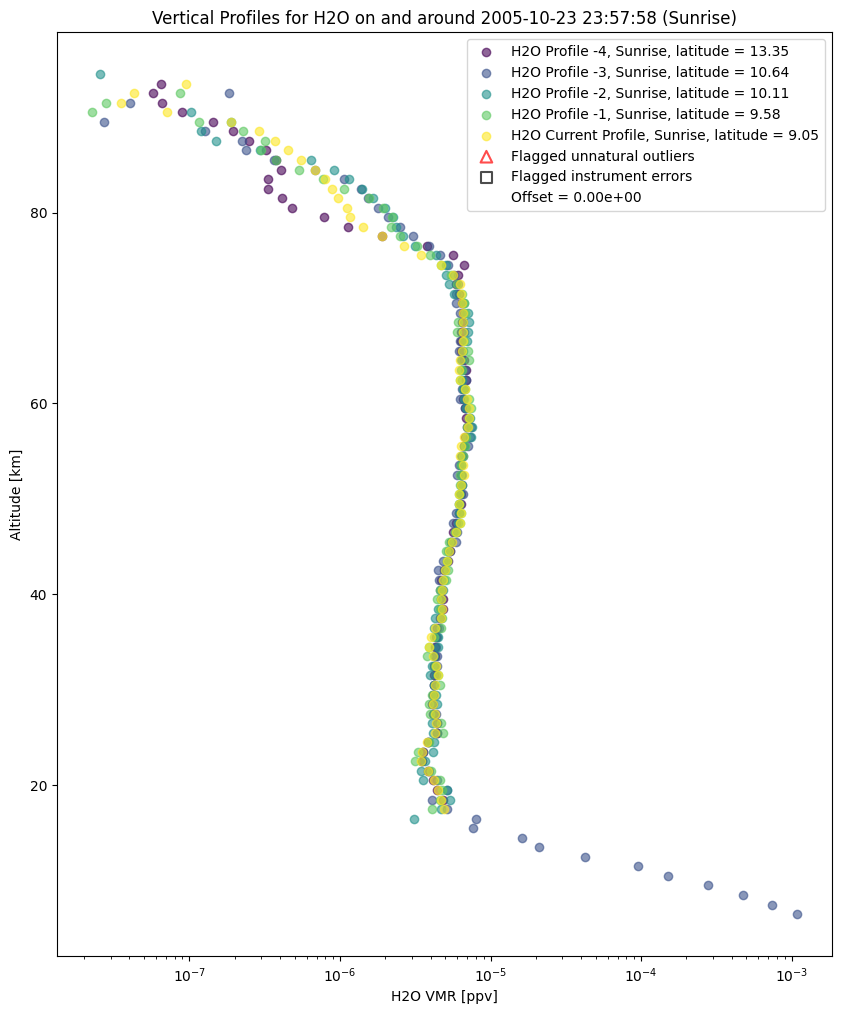

In [73]:
reload(data_processing)
from data_processing import vertical_profile_plot as vpp

idx = np.random.choice(predicted_bad_indices)
print(idx)

date_indices_example = feature_date_indices[idx]

vpp('H2O', h2o_data, h2o_flags, date_indices_example)

In [75]:
# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

587/587 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - binary_accuracy_with_threshold: 0.9652 - loss: 0.1091
Test Loss: 0.11663886904716492, Test Accuracy: 0.963152289390564


In [83]:
import shap

/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [101]:
tf.config.run_functions_eagerly(True)

In [111]:
background_data = X_train[0:100]
data_to_explain = X_test

def predict_fn(data):
    return model.predict(data)

# Initialize the SHAP explainer
explainer = shap.KernelExplainer(predict_fn, background_data)

# Compute SHAP values
shap_values = explainer.shap_values(data_to_explain[:10])

# Visualize SHAP summary plot
shap.summary_plot(shap_values[0], data_to_explain[:10])

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

/Users/jamesharvey/MPhys_Project/.venv/lib/python3.10/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


DimensionError: Instance must have 1 or 2 dimensions!